In [190]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns


from dtw import dtw
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [191]:
def load_audio_segments(base_path):
    """
    Загружает аудио сегменты из папок в структурированный формат
    """
    data = []
    
    # Проходим по всем папкам
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        
        if os.path.isdir(folder_path):
            print(f"Загружаем файлы из папки: {folder_name}")
            
            # Проходим по всем файлам в папке
            for file_name in sorted(os.listdir(folder_path)):
                if file_name.startswith(folder_name) and file_name.endswith('.wav'):
                    file_path = os.path.join(folder_path, file_name)
                    
                    try:
                        # Загружаем аудиофайл
                        audio, sr = librosa.load(file_path, sr=22050)
                        
                        # Извлекаем номер сегмента из имени файла
                        segment_num = int(file_name.split('_')[-1].split('.')[0])
                        
                        data.append({
                            'audio': audio,
                            'sampling_rate': sr,
                            'label': folder_name,
                            'segment_number': segment_num,
                            'duration': len(audio) / sr
                        })
                        
                    except Exception as e:
                        print(f"Ошибка при загрузке {file_path}: {e}")
    
    # Создаем DataFrame
    df = pd.DataFrame(data)
    return df

base_path = "SOUNDS/"
audio_df = load_audio_segments(base_path)

print(f"Загружено {len(audio_df)} файлов")
print("Уникальные классы:", audio_df['label'].unique())
print(audio_df.head())

Загружаем файлы из папки: distributivi
Загружаем файлы из папки: dokumenti
Загружаем файлы из папки: filmi
Загружаем файлы из папки: fotografii
Загружаем файлы из папки: igri
Загружаем файлы из папки: knigi
Загружаем файлы из папки: musika
Загружаем файлы из папки: proekti
Загружаем файлы из папки: zagruzki
Загружено 135 файлов
Уникальные классы: ['distributivi' 'dokumenti' 'filmi' 'fotografii' 'igri' 'knigi' 'musika'
 'proekti' 'zagruzki']
                                               audio  ...  duration
0  [0.0008544922, 0.009460449, 0.012878418, 0.006...  ...  1.047664
1  [-0.00015258789, -0.00061035156, -0.0011901855...  ...  1.242222
2  [-0.019927979, -0.01473999, -0.011810303, -0.0...  ...  1.017732
3  [0.006591797, 0.007385254, 0.0078125, 0.008239...  ...  1.197324
4  [-9.1552734e-05, -9.1552734e-05, -3.0517578e-0...  ...  1.137460

[5 rows x 5 columns]


In [192]:
audio_df['label'].value_counts()

label
distributivi    15
dokumenti       15
filmi           15
fotografii      15
igri            15
knigi           15
musika          15
proekti         15
zagruzki        15
Name: count, dtype: int64

In [193]:
def extract_mfcc_features(audio_df, n_mfcc=13, frame_length=2048, hop_length=512):
    """
    Извлекает MFCC признаки из аудио сегментов
    """
    
    mfcc_features = []
    
    for idx, row in audio_df.iterrows():
        audio = row['audio']
        sr = row['sampling_rate']
        
        # Извлекаем MFCC признаки
        mfcc = librosa.feature.mfcc(
            y=audio, 
            sr=sr, 
            n_mfcc=n_mfcc,
            n_fft=frame_length,
            hop_length=hop_length
        )
        mfcc = mfcc.ravel(order="F")
        
        mfcc_features.append({
            'label': row['label'],
            'segment_number': row['segment_number'],
            'mfcc_matrix': mfcc,
        })
        
    return pd.DataFrame(mfcc_features)

# Использование функции
print("Извлечение MFCC признаков...")
mfcc_features_df = extract_mfcc_features(audio_df, n_mfcc=13)

Извлечение MFCC признаков...


In [194]:
print("\nПервые 5 записей:")
mfcc_features_df.iloc[0:100]


Первые 5 записей:


,label,segment_number,mfcc_matrix
0,distributivi,1,"[-398.4823, 99.40163, -1.0410377, 95.926994, -..."
1,distributivi,2,"[-513.7162, 177.79803, 46.862354, 31.449303, 2..."
2,distributivi,3,"[-351.7988, 76.669556, 16.731697, 76.964676, -..."
3,distributivi,4,"[-491.99164, 148.94333, 43.237625, 43.68419, 2..."
4,distributivi,5,"[-531.1481, 151.50888, 41.41855, 25.740913, 17..."
...,...,...,...
95,musika,6,"[-428.66833, 154.5213, 8.230299, 1.6192532, 7...."
96,musika,7,"[-440.39313, 159.98386, 12.834754, 3.2106133, ..."
97,musika,8,"[-372.0175, 144.32101, 12.085356, 19.120785, 1..."
98,musika,9,"[-413.87534, 154.69608, -5.2005224, 17.472668,..."


In [195]:
def split_dataset(mfcc_features_df, random_state=42):
    """
    Разбивает данные на обучающую и тестовую выборки
    """
    # Проверяем, что у нас есть 15 сегментов
    unique_segments = mfcc_features_df['segment_number'].unique().tolist()
    print(f"Уникальные номера сегментов: {sorted(unique_segments)}")
    print(f"Всего сегментов: {len(unique_segments)}")
    
    # Группируем по меткам (классам)
    unique_labels = mfcc_features_df['label'].unique().tolist()
    print(f"Уникальные классы: {unique_labels}")
    
    # Создаем списки для train и test
    train_indices = []
    test_indices = []
    
    # Для каждого класса выбираем тестовые сегменты
    for label in unique_labels:
        label_data = mfcc_features_df[mfcc_features_df['label'] == label]
        
        # Получаем все сегменты для этого класса
        segments = sorted(label_data['segment_number'].unique().tolist())
        print(f"Класс {label}: сегменты {segments}")
        
        # Выбираем тестовые сегменты (примерно 20% от 15 = 3 сегмента)
        test_segments = sorted(np.random.choice(segments, size=3, replace=False).tolist())
        train_segments = [s for s in segments if s not in test_segments]
        
        print(f"  Train сегменты: {train_segments}")
        print(f"  Test сегменты: {test_segments}")
        
        # Добавляем индексы в соответствующие списки
        train_indices.extend(label_data[label_data['segment_number'].isin(train_segments)].index.tolist())
        test_indices.extend(label_data[label_data['segment_number'].isin(test_segments)].index.tolist())
    
    # Создаем train и test DataFrame
    train_df = mfcc_features_df.loc[train_indices].reset_index(drop=True)
    test_df = mfcc_features_df.loc[test_indices].reset_index(drop=True)
    
    return train_df, test_df

In [196]:
print("Разбиваем данные на обучающую и тестовую выборки...")
train_df, test_df = split_dataset(mfcc_features_df)

print(f"\nРазмер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"Соотношение train/test: {len(train_df)/len(mfcc_features_df):.2f}/{len(test_df)/len(mfcc_features_df):.2f}")

# Проверяем распределение классов в обеих выборках
print("\nРаспределение классов в обучающей выборке:")
print(train_df['label'].value_counts())

print("\nРаспределение классов в тестовой выборке:")
print(test_df['label'].value_counts())

Разбиваем данные на обучающую и тестовую выборки...
Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 8, 9, 12, 13, 14, 15]
  Test сегменты: [7, 10, 11]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15]
  Test сегменты: [2, 3, 11]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15]
  Test сегменты: [1, 10, 11]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15]
  Test сегменты: [1, 10, 13]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 

In [197]:
train_df.iloc[:15]

,label,segment_number,mfcc_matrix
0,distributivi,1,"[-398.4823, 99.40163, -1.0410377, 95.926994, -..."
1,distributivi,2,"[-513.7162, 177.79803, 46.862354, 31.449303, 2..."
2,distributivi,3,"[-351.7988, 76.669556, 16.731697, 76.964676, -..."
3,distributivi,4,"[-491.99164, 148.94333, 43.237625, 43.68419, 2..."
4,distributivi,5,"[-531.1481, 151.50888, 41.41855, 25.740913, 17..."
5,distributivi,6,"[-339.69836, 73.5452, -0.4635982, 87.870056, -..."
6,distributivi,8,"[-335.7862, 64.98307, 1.4001234, 88.25701, -6...."
7,distributivi,9,"[-398.36084, 87.77872, 24.458973, 69.63151, 1...."
8,distributivi,12,"[-360.9511, 115.17311, 24.737595, 22.279026, 1..."
9,distributivi,13,"[-341.75403, 68.35047, -10.265001, 94.85293, -..."


In [198]:
X_train = train_df['mfcc_matrix'].values
y_train = train_df['label'].values

X_test = test_df['mfcc_matrix'].values
y_test = test_df['label'].values

print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

Обучающая выборка: 108 примеров
Тестовая выборка: 27 примеров


In [199]:
import time
def dtw_distance(mfcc1, mfcc2):
    return dtw(mfcc1, mfcc2, dist_method='euclidean').distance

def dtw_knn_predict(X_train, y_train, X_test, k=1):
    start = time.time()
    y_pred = []
    for i, test_mfcc in enumerate(X_test):
        if i % 5 == 0 or i == len(X_test) - 1:
            print(f"Прогресс: {i+1}/{len(X_test)} ({(i+1)/len(X_test)*100:.2f}%)")
        distances = []
        for train_mfcc, label in zip(X_train, y_train):
            distances.append((label, dtw_distance(test_mfcc, train_mfcc)))
        distances.sort(key=lambda x: x[1])
        labels = [label for label, _ in distances[:k]]
        y_pred.append(max(set(labels), key=labels.count))
    end = time.time()
    print(f"Время выполнения: {end-start:.4f} секунд")
    return y_pred
    

Прогресс: 1/27 (3.70%)
Прогресс: 6/27 (22.22%)
Прогресс: 11/27 (40.74%)
Прогресс: 16/27 (59.26%)
Прогресс: 21/27 (77.78%)
Прогресс: 26/27 (96.30%)
Прогресс: 27/27 (100.00%)
Время выполнения: 25.2156 секунд

Точность DTW (1-NN): 1.0000 (100.00%)

Отчёт по классификации:
              precision    recall  f1-score   support

distributivi       1.00      1.00      1.00         3
   dokumenti       1.00      1.00      1.00         3
       filmi       1.00      1.00      1.00         3
  fotografii       1.00      1.00      1.00         3
        igri       1.00      1.00      1.00         3
       knigi       1.00      1.00      1.00         3
      musika       1.00      1.00      1.00         3
     proekti       1.00      1.00      1.00         3
    zagruzki       1.00      1.00      1.00         3

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



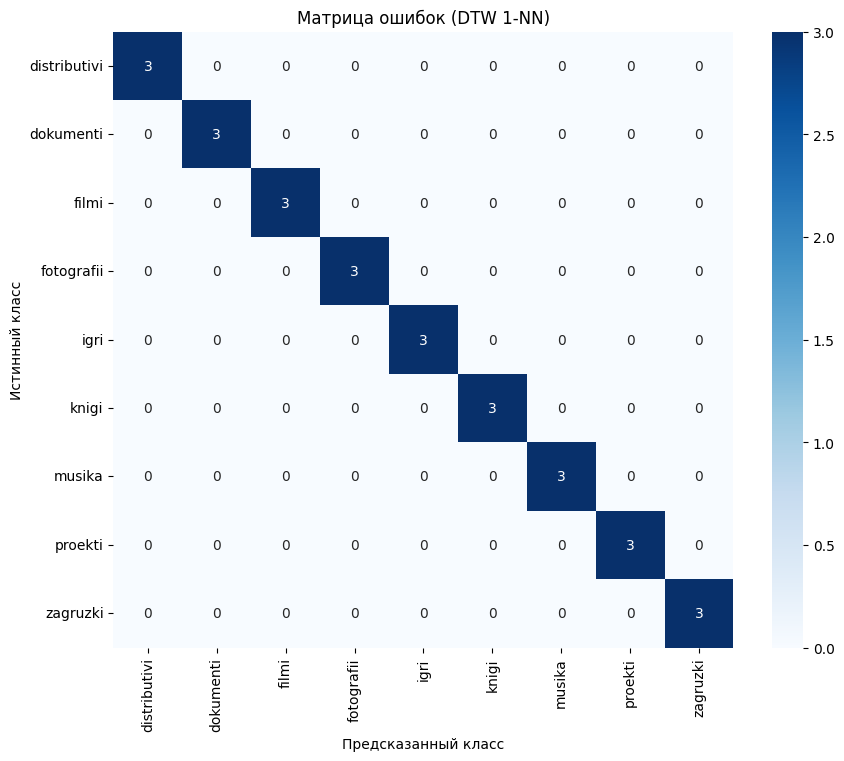

In [200]:
y_pred = dtw_knn_predict(X_train, y_train, X_test, k=3)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность DTW (1-NN): {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_train)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_train)),
            yticklabels=sorted(np.unique(y_train)))
plt.title('Матрица ошибок (DTW 1-NN)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [201]:
def norm_X(X, k):
    new_X = []
    for row in X:
        new_row = np.zeros(k)
        for i, item in enumerate(row):
            new_row[i % 13] = new_row[i % k] + item / (len(row) / k)
        new_X.append(new_row)
    return new_X

In [202]:
from sklearn.preprocessing import StandardScaler
X_train_N = norm_X(X_train, 13)
X_test_N = norm_X(X_test, 13)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_N)
X_test_scaled = scaler.transform(X_test_N)


In [203]:
from sklearn.preprocessing import OneHotEncoder

# Создаём и настраиваем OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,  # возвращаем плотный массив (не sparse matrix)
    categories='auto'       # автоматически определит категории из данных
)

# Применяем кодирование
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.fit_transform(y_test.reshape(-1, 1))
print(y_train_encoded.shape)
print(y_test_encoded.shape)


(108, 9)
(27, 9)


In [204]:
print("X_train_N shape:", X_train_scaled.shape)
print("y_train_encoded shape:", y_train_encoded.shape)

print("X_test_N shape:", X_test_scaled.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

X_train_N shape: (108, 13)
y_train_encoded shape: (108, 9)
X_test_N shape: (27, 13)
y_test_encoded shape: (27, 9)


In [205]:
from keras import layers, models
from keras.optimizers import Adam

model = models.Sequential()

model.add(layers.Dense(64, activation='relu', input_shape=(13,)))
model.add(layers.Dense(39, activation='relu'))
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(9, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


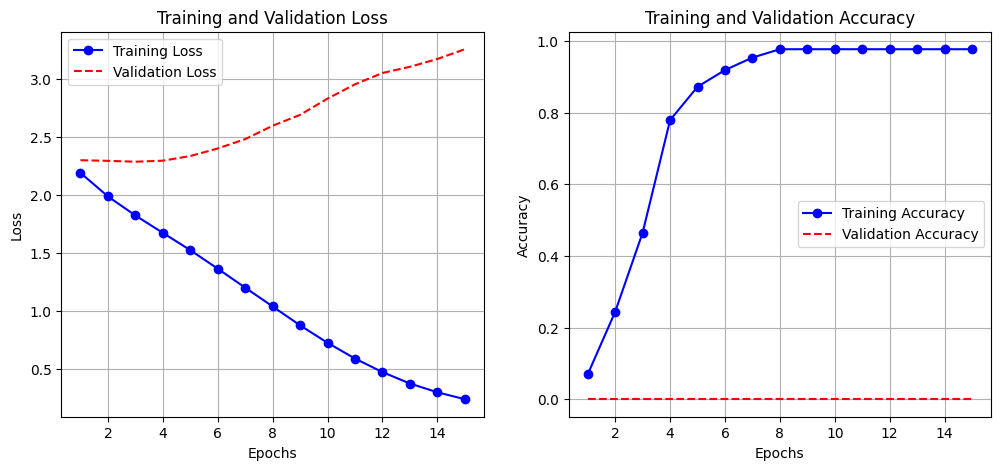

In [206]:
history = model.fit(
    X_train_scaled,             
    y_train_encoded,         
    epochs=15,             
    batch_size=16,           
    validation_split=0.2,    
    verbose=0,
    shuffle=True        
)

# Извлекаем значения потерь и точности
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Время выполнения: 0.1407 секунд

Точность нейронной сети: 0.7778 (77.78%)

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.75      1.00      0.86         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       0.60      1.00      0.75         3
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3

    accuracy                           0.78        27
   macro avg       0.63      0.78      0.69        27
weighted avg       0.63      0.78      0.69        27



c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

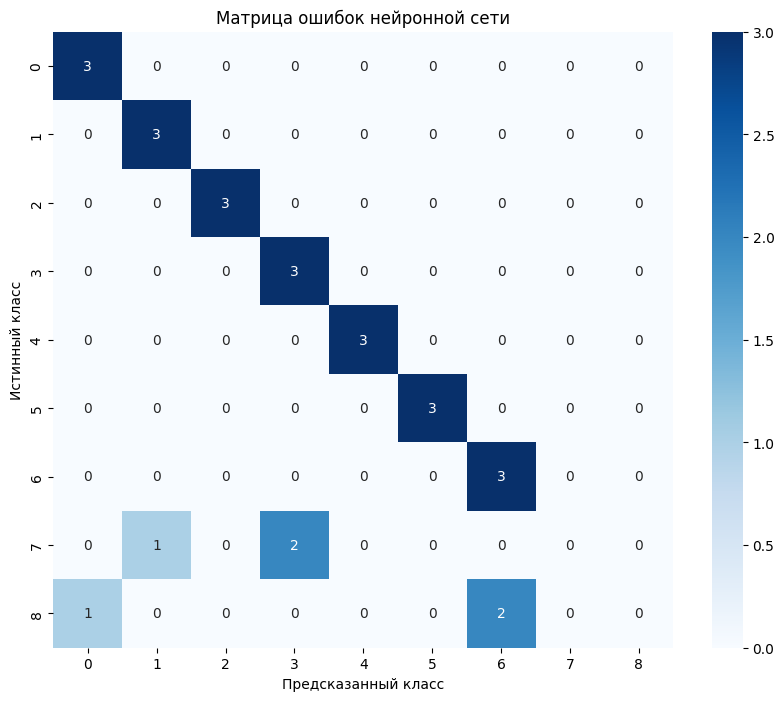

In [207]:
start = time.time()
y_pred_2 = model.predict(X_test_scaled)
end = time.time()
print(f"Время выполнения: {end-start:.4f} секунд")
y_pred_2 = np.argmax(y_pred_2, axis=1)

y_test_argmax = np.argmax(y_test_encoded, axis=1)

accuracy = accuracy_score(y_test_argmax, y_pred_2)
print(f"\nТочность нейронной сети: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test_argmax, y_pred_2))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test_argmax, y_pred_2, labels=sorted(np.unique(y_test_argmax)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_test_argmax)),
            yticklabels=sorted(np.unique(y_test_argmax)))
plt.title('Матрица ошибок нейронной сети')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()
